
=== hybrid_edge_X_0.5_Y_0.5_hybrid_edge_20260731_070706 ===


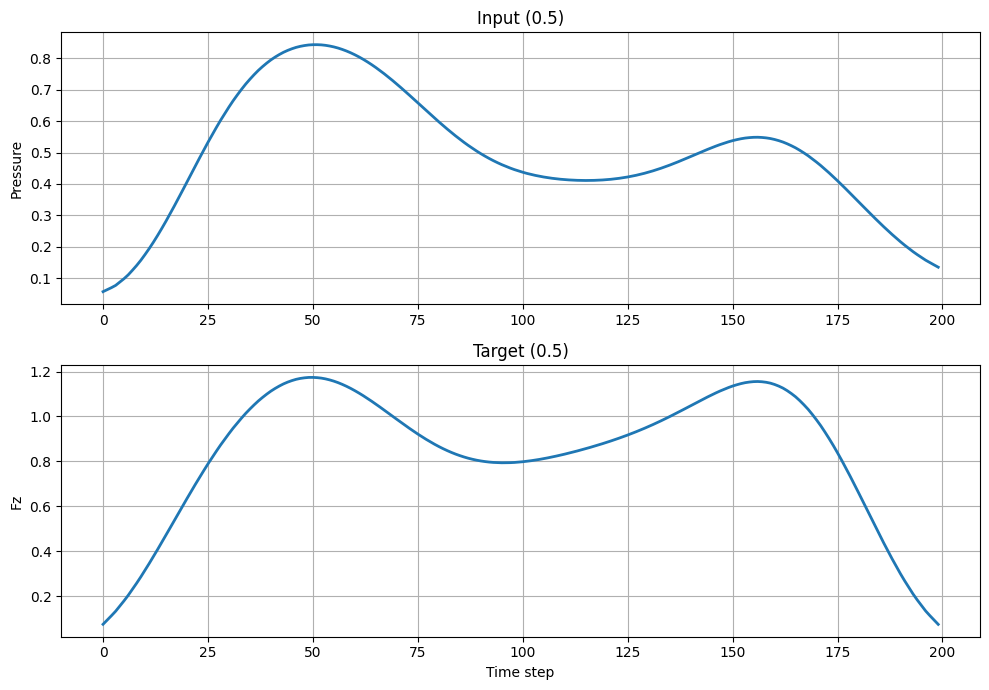

保存: /home/human/Research/outputs/experiments/hybrid_edge_X_0.5_Y_0.5_hybrid_edge_20260731_070706/stride_verification.png

=== hybrid_edge_X_1.0_post_swing_Y_0.5_hybrid_edge_20260731_075043 ===


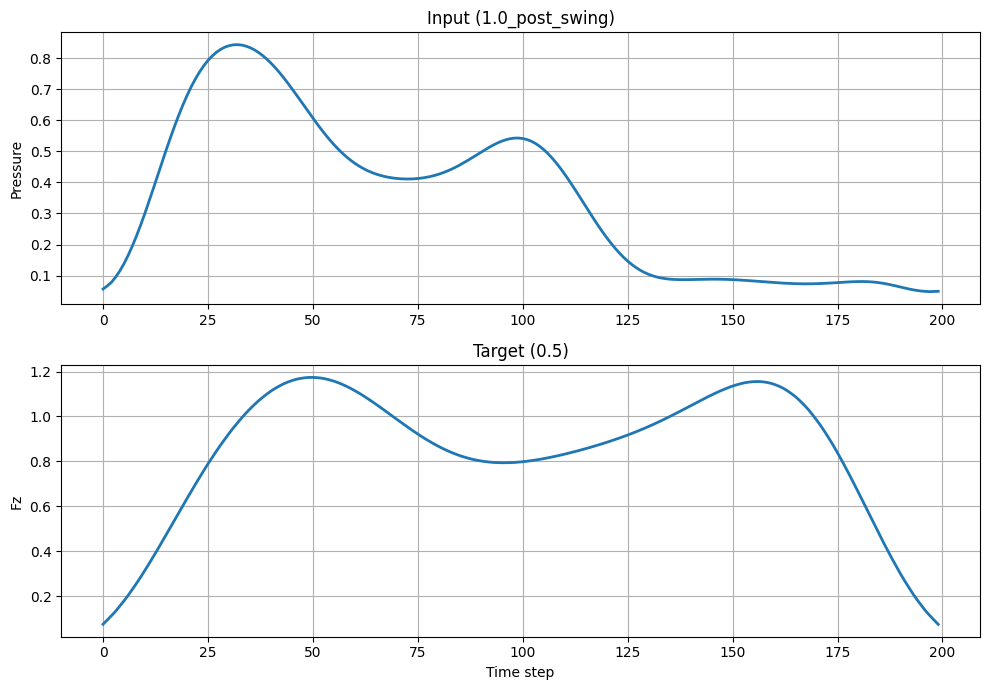

保存: /home/human/Research/outputs/experiments/hybrid_edge_X_1.0_post_swing_Y_0.5_hybrid_edge_20260731_075043/stride_verification.png

=== hybrid_edge_X_1.0_pre_swing_Y_0.5_hybrid_edge_20260731_073118 ===


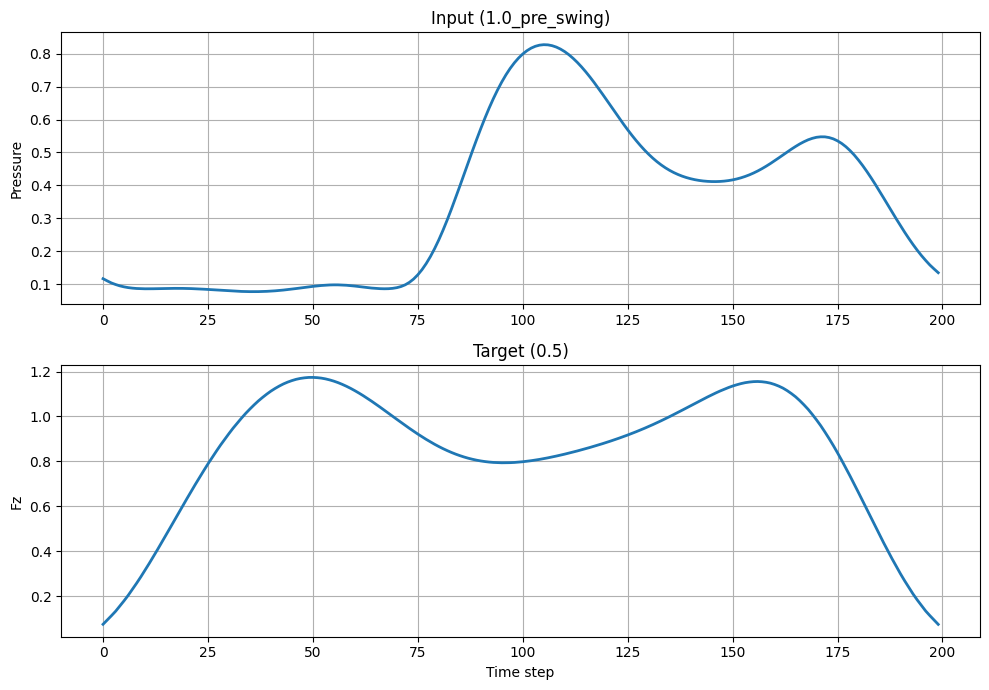

保存: /home/human/Research/outputs/experiments/hybrid_edge_X_1.0_pre_swing_Y_0.5_hybrid_edge_20260731_073118/stride_verification.png

=== hybrid_edge_X_1.5_Y_0.5_hybrid_edge_20260731_080736 ===


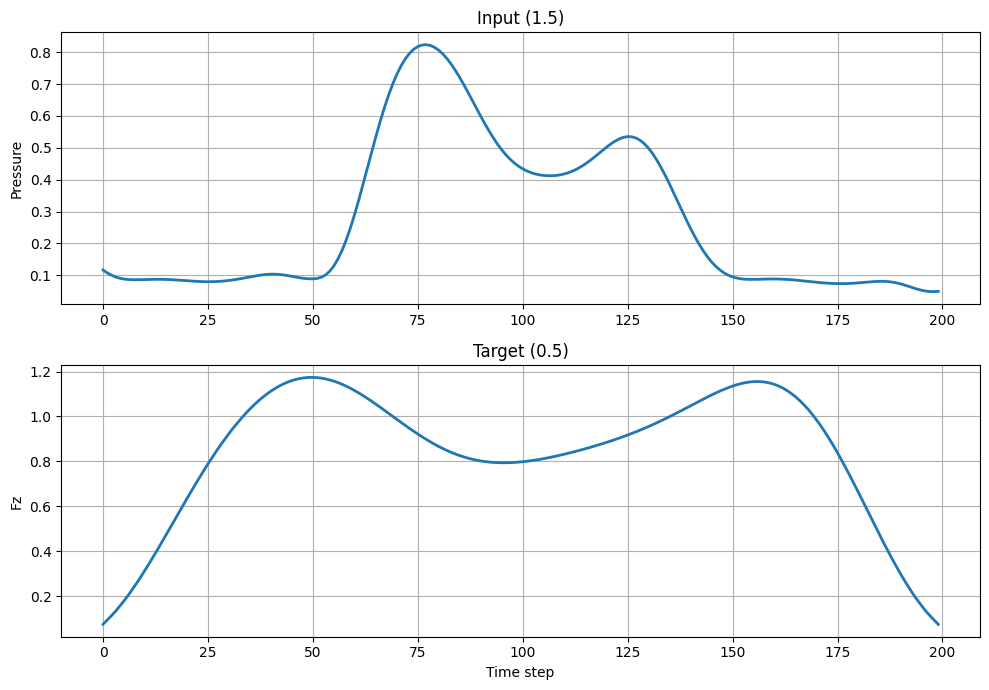

保存: /home/human/Research/outputs/experiments/hybrid_edge_X_1.5_Y_0.5_hybrid_edge_20260731_080736/stride_verification.png


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def visualize_experiment_strides(exp_dir):
    exp_path = Path(exp_dir)

    config_file = exp_path / "config.json"
    inputs_file = exp_path / "inputs_fold1.npy"
    targets_file = exp_path / "targets_fold1.npy"

    if not (config_file.exists() and inputs_file.exists() and targets_file.exists()):
        print(f"必要なファイルが {exp_dir} に見つかりません")
        return

    with open(config_file, "r") as f:
        config = json.load(f)

    target_type = config.get("target_type", "grf_only")
    config_x = config.get("stride_type_X", "unknown")
    config_y = config.get("stride_type_Y", "unknown")

    print(f"\n=== {exp_path.name} ===")

    inputs = np.load(inputs_file)
    targets = np.load(targets_file)

    # 同側足底圧力(8ch)
    mean_input_pressure = np.mean(
        np.sum(inputs[:, :, 0:8], axis=2),
        axis=0
    )

    # Target Fz
    if target_type == "grf_only":
        fz_idx = 2
    elif target_type == "all":
        fz_idx = 11
    else:
        fz_idx = -1

    if fz_idx != -1:
        mean_target_fz = np.mean(targets[:, :, fz_idx], axis=0)
    else:
        mean_target_fz = np.mean(np.sum(np.abs(targets), axis=2), axis=0)

    # Plot
    fig, axs = plt.subplots(2, 1, figsize=(10, 7))

    axs[0].plot(mean_input_pressure, lw=2)
    axs[0].set_title(f"Input ({config_x})")
    axs[0].set_ylabel("Pressure")
    axs[0].grid(True)

    axs[1].plot(mean_target_fz, lw=2)
    axs[1].set_title(f"Target ({config_y})")
    axs[1].set_ylabel("Fz")
    axs[1].set_xlabel("Time step")
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()


# ===========================================================
# ここに確認したい実験フォルダを並べる
# ===========================================================
experiment_paths = [
    "/home/human/Research/outputs/experiments/hybrid_edge_X_0.5_Y_0.5_hybrid_edge_20260731_070706",
    "/home/human/Research/outputs/experiments/hybrid_edge_X_1.0_post_swing_Y_0.5_hybrid_edge_20260731_075043",
    "/home/human/Research/outputs/experiments/hybrid_edge_X_1.0_pre_swing_Y_0.5_hybrid_edge_20260731_073118",
    "/home/human/Research/outputs/experiments/hybrid_edge_X_1.5_Y_0.5_hybrid_edge_20260731_080736"
    ""
]

# ===========================================================
# 実行
# ===========================================================
for exp_dir in experiment_paths:
    visualize_experiment_strides(exp_dir)